## 1 Gerade durch zwei experimentelle Messungen und Fehler

Am Mittwoch werden Sie lernen, wie man eine Gerade an beliebig viele Messungen anpasst.
Für die Übungen zur Fehlerrechnung betrachten wir nun den Fall mit zwei Messwerten, der eine analytische Lösung hat. Wir benutzen dabei das gestriege Beispiel der Stromstärkemessungen und verwenden nur die erste und die letzte Messung ($U_1,I_1$) und ($U_{10}, I_{10}$).

Die Gerade ist dann $I_i = m U_i + a$.

Mit $m = \frac{I_{10} - I_1}{U_{10}-U_1}$ und $a= I_1 - \frac{I_{10} - I_1}{U_{10}-U_1} U_1$.

[]

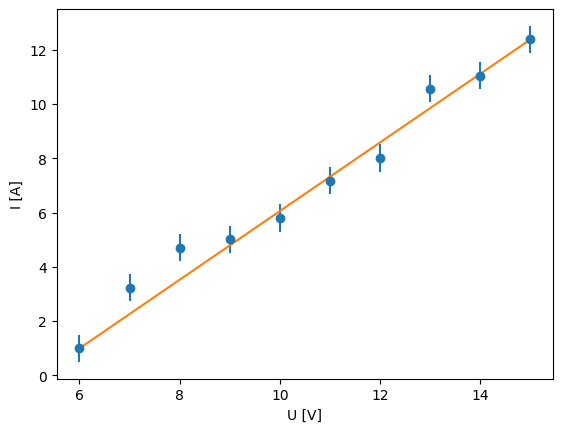

In [1]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
U = np.arange(6,15.4,1)
mus = 1.2*(U-5)
Ierr = 0.5
I = stats.norm.rvs(mus, Ierr)
m=(I[-1]-I[0])/(U[-1]-U[0])
a= I[0] - (I[-1]-I[0])/(U[-1]-U[0])*U[0]
plt.errorbar(U, I,yerr=Ierr, fmt='o')
plt.plot(U, m*U+a)
plt.xlabel("U [V]")
plt.ylabel("I [A]")
plt.plot()

### 1.1 Steigung und Achsenabschnitt
Berechnen Sie $m$ und $a$. 
Zeichnen Sie als Test Ihre Gerade ein. Geht die Gerade exakt durch den ersten und letzten Messpunkt?

### 1.2 Fehlerrechnung
Berechnen Sie nun mit Fehlerfortpflanzung jeweils den Fehler auf die Steigung $m$ und den Achsenabschnitt $a$.

Führen Sie Variablen für $\frac{dm}{dI_1}, \frac{dm}{dI_{10}} \frac{da}{dI_1}$ und  $\frac{da}{dI_{10}}$ ein und geben Sie die Werte der Ableitungen und die endgültigen Fehler aus.

In [2]:
from IPython.display import display, Math


dmdI1  = -1/(U[-1]-U[0])
dmdI10 = 1/(U[-1]-U[0])
dadI1  = U[-1]/(U[-1]-U[0])
dadI10 = -U[0]/(U[-1]-U[0])

sig_m= np.sqrt(dmdI1**2 * Ierr**2 + dmdI10**2 * Ierr**2)
sig_a =np.sqrt(dadI1**2 * Ierr**2 + dadI10**2 * Ierr**2)

print(m, "±", sig_m)
print(a,"±", sig_a)
#print(rf"$\frac{{dm}}{{dI_1}} =$", dmdI1, "$\frac{{dm}}{{dI_{10}}}=$", dmdI10 ,"$\frac{{da}}{{dI_1}}=$", dadI1 , "$ \\frac{{da}}{{dI_{10}}}=$", dadI10)
display(Math(rf"\frac{{dm}}{{dI_1}} = {dmdI1:.3f} \quad "
             rf"\frac{{dm}}{{dI_{{10}}}} = {dmdI10:.3f} \quad "
             rf"\frac{{da}}{{dI_1}} = {dadI1:.3f} \quad "
             rf"\frac{{da}}{{dI_{{10}}}} = {dadI10:.3f}"))


1.2653670534140584 ± 0.07856742013183861
-6.59733602117991 ± 0.8975274678557507


<IPython.core.display.Math object>

### 1.3 Überprüfung durch Monte Carlo

Der unterstehende Code-Block simuliert $10\,000$  Stromstärkemessreihen. Berechnen Sie für jede Messreihe $i$ die Steigung $m_i$ und den Achsenabschnitt $a_i$. 
Zeichnen Sie je ein Histogramm für die Steigungen und Achsenabschnitte der $10\,000$ Stromstärkemessreihen

Vergleichen Sie die Standardabweichungen der Steigungs- und Achsenabschnittstichproben mit den berechneten Fehlern aus 1.2.

Stimmen die Werte überein?

In [3]:
ngen=10000
mus_gen = np.repeat(mus, ngen).reshape((-1,ngen))
I_sample = stats.norm.rvs(mus_gen, Ierr)
I_sample

array([[ 1.57816411,  1.10056223,  1.33316199, ...,  1.30030756,
         1.47959872,  1.28518586],
       [ 1.66760559,  2.56158518,  2.24360045, ...,  2.78042412,
         2.21957109,  2.8755082 ],
       [ 2.89283197,  2.3585905 ,  3.51876152, ...,  4.28812629,
         3.78360301,  3.02445411],
       ...,
       [ 9.21228464,  9.71447624,  9.99285863, ...,  9.469207  ,
         9.80682431,  9.9915394 ],
       [10.05892855, 10.22858791, 11.15912961, ..., 10.3847954 ,
        11.01201903, 10.38703002],
       [11.82031034, 12.77492   , 11.89549423, ..., 12.11250544,
        12.21003791, 11.95725822]])

Text(0.5, 0, 'm')

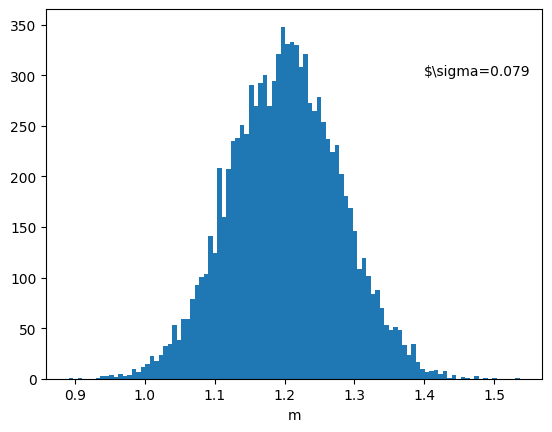

In [4]:
m_sample=(I_sample[9,:]-I_sample[0,:])/(U[9]-U[0])
a_sample= I_sample - m*U[0]
m_sample, a_sample
plt.hist(m_sample, bins=100)
plt.text(1.4,300,f"$\\sigma={np.std(m_sample,ddof=1):0.3f}")
plt.xlabel("m")

# 1.4 Fehlerrechnung 2

Berechnen Sie nun für  die in 1.1 gefundene Gerade die Funktionswerte bei U=6 V, 10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die schon berechneten Fehler auf $m$ und $a$ fortpflanzen. Schreiben Sie dafür je eine Funktion, für die Geradenwerte und eine für die Fehler. 
```
def func(U, m, a):
    return m*U +a

def func_err(U, merr, aerr):
    dfdm = 
    dfda = 
    return np.sqrt(dfdm*dfdm*merr*merr + dfda*dfda*aerr*aerr)
```


Ergeben diese Werte Sinn? Welche Fehler würden Sie für die Messstellen 6 V und 15 V erwarten?

In [5]:
U_test=[6,10,11,15]
m=(I[-1]-I[0])/(U[-1]-U[0])
a= I[0] - (I[-1]-I[0])/(U[-1]-U[0])*U[0]

def func(U, m, a):
    return m*U +a

def func_err(U, merr, aerr):
    dfdm = U
    dfda = 1
    return np.sqrt(dfdm*dfdm*merr*merr + dfda*dfda*aerr*aerr)

for u in U_test:
    print(f"for U = {u}V: I = {func(u, m, a):.3f}±{func_err(u, m, a):.3f}")

for U = 6V: I = 0.995±10.058
for U = 10V: I = 6.056±14.270
for U = 11V: I = 7.322±15.403
for U = 15V: I = 12.383±20.094


## 1.5  Überprüfung durch Monte Carlo

Überprüfen Sie wiederum die gefundenen Fehler mit den Geraden aus den $10\,000$ Messreihen.
Mit den Steigungs- und Achsenabschnittswerten ($m_i, a_i$) aus 1.3 können die Funktionswerte für jede Messreihe berechnet werden. 

In [6]:
#plt.plot(Us,m_sample[0]*Us + a_sample[0])
#plt.plot(Us,m_sample[1]*Us + a_sample[1])
#plt.plot(Us,m_sample[2]*Us + a_sample[2])
Us = np.linspace(5,16,200)
for i in range(1000):
    plt.plot(Us,m_sample[i]*Us + a_sample[i])

plt.vlines([6,10,11,15], -2, 15, ls='dotted')
plt.xlabel("U [V]")
plt.xlabel("I [A]")

plt.show()

ValueError: operands could not be broadcast together with shapes (200,) (10000,) 

Berechnen Sie mit den Steigungs- und Achsenabschnittswerten ($m_i, a_i$) aus 1.3 die Stromstärkewerte bei U=6 V, 10 V, 11 V und 15 V mit $I_i(U) = m_i U + a_i$.
Zeichnen Sie die vier Histogramme der Stromstärkewerte.

Geben Sie die Standardabweichungen der vier Verteilungen aus.


Was beobachten Sie?

In [ ]:
U_test2=[6,10,11,15]

fig, axes =plt.subplots(1, 4, figsize=(20, 5))

#for i,u in enumerate(U_test2):
    axes[i].hist(m_sample*u + a_sample, bins=50)
    axes[i].set_title('U={u}V')
    axes[i].set_xlabel('$I_i(U) [A]$')

KeyboardInterrupt: 

## 2 Alternative Geradenparametrisierung

Entwickeln Sie nun die Gerade um den Schwerpunkt (Mittelwert) $\hat U$ der Spannungswerte, an denen gemessen wurde.


Also: $I(U) = m (U-\hat U) + b$

Die Konstante $b$ ist nun nicht mehr der Achsenabschnitt, sondern der Funktionswert bei $U=\hat U$.

Die Formel für die Steigung $m$ ändert sich nicht und der Parameter $b$ ist dann mit $\hat U = \frac{U_1 + U_{10}}{2} = 25{,}5$ V:

$ b = I_1 - \frac{I_{10} - I_1}{U_{10}-U_1} (U_1 - \hat U)  =  I_1 - \frac{(I_{10} - I_1)(2U_1 - U_{1} - U{10})}{2(U_{10}-U_1)} = I_1 - \frac{(I_{10} - I_1)(U_{1} - U_{10})}{2(U_{10}-U_1)} =  I_1 + \frac{I_{10} - I_1}{2} = \frac{I_1 + I_{10}}{2}= \hat I$

#### 2.1 Parameterberechnung
Berechnen Sie $b$ und zeichnen Sie die Gerade in die Daten ein.

In [ ]:
U_mean= (U[-1]+U[0])/2
m=(I[-1]-I[0])/(U[-1]-U[0])
b=I[0]-m*(U[0]-U_mean)

### 2.2 Fehlerrechnung
Berechnen Sie nun mit Fehlerfortpflanzung jeweils den Fehler auf die Steigung $m$ und den Parameter $b$.

Führen Sie Variablen für $\frac{dm}{dI_1}, \frac{dm}{dI_{10}} \frac{db}{dI_1}$ und  $\frac{db}{dI_{10}}$ ein und geben Sie die Werte der Ableitungen und die endgültigen Fehler aus.

In [9]:
dmdI1  = -1/(U[-1]-U[0])
dmdI10 = 1/(U[-1]-U[0])
dbdI1  = 0.5
dbdI10 = 0.5

sig_m= np.sqrt(dmdI1**2 * Ierr**2 + dmdI10**2 * Ierr**2)
sig_b =np.sqrt(dbdI1**2 * Ierr**2 + dbdI10**2 * Ierr**2)

print(m, "±", sig_m)
print(a,"±", sig_a)
#print(rf"$\frac{{dm}}{{dI_1}} =$", dmdI1, "$\frac{{dm}}{{dI_{10}}}=$", dmdI10 ,"$\frac{{da}}{{dI_1}}=$", dadI1 , "$ \\frac{{da}}{{dI_{10}}}=$", dadI10)
display(Math(rf"\frac{{dm}}{{dI_1}} = {dmdI1:.3f} \quad "
             rf"\frac{{dm}}{{dI_{{10}}}} = {dmdI10:.3f} \quad "
             rf"\frac{{da}}{{dI_1}} = {dbdI1:.3f} \quad "
             rf"\frac{{da}}{{dI_{{10}}}} = {dbdI10:.3f}"))


1.2653670534140584 ± 0.07856742013183861
-6.59733602117991 ± 0.8975274678557507


<IPython.core.display.Math object>

### 2.3 Überprüfung durch Monte Carlo

Benutzen Sie die selben simulierten 10 000 Stromstärkemessreihen aus Aufgabe 1. Berechnen Sie für jede Messreihe die Steigung und den Funktionswert im Schwerpunkt $b$. Vergleichen Sie die Standardabweichungen der $m$- und $b$-Stichproben mit den berechneten Fehlern aus 2.2.

Stimmen die Werte überein?

### 2.4 Fehlerrechnung 2

Berechnen Sie nun für  die in 2.1 gefundene Gerade die Funktionswerte bei U=6 V, 10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die schon berechneten Fehler auf $m$ und $a$ fortpflanzen. Schreiben Sie dafür je eine Funktion, für die Geradenwerte und eine für die Fehler. 
```
def func2(U, m, b):
    return m*(U-Uhat) +b

def func2_err(U, merr, berr):
    dfdm = 
    dfdb = 
    return np.sqrt(dfdm*dfdm*merr*merr + dfdb*dfdb*berr*berr)
```


Ergeben diese Werte Sinn?

In [12]:
def func2(U, m, b):
    return m*(U-U_mean) +b

def func2_err(U, merr, berr):
    dfdm = (U-U_mean)
    dfdb = 1
    return np.sqrt(dfdm*dfdm*merr*merr + dfdb*dfdb*berr*berr)

for u in U_test:
    print(f"for U = {u}V: I = {func(u, m, b):.3f}±{func_err(u, m, b):.3f}")

for U = 6V: I = 14.281±10.119
for U = 10V: I = 19.343±14.313
for U = 11V: I = 20.608±15.443
for U = 15V: I = 25.670±20.125


## 2.5  Überprüfung durch Monte Carlo

Überprüfen Sie wiederum die gefundenen Fehler mit den $b$- und $m$-Werte aus der Simulation in 2.3.

Was beobachten Sie?

## 2.6 
Wie kommt es zu er dramatischen Diskrepanz im Vergleich zur anderen Parametrisierung?
Welche Methode ist also zu wählen?

**Slides**

## 3 Volle Fehlerfortpflanzung

Wir betrachten nun wieder das Beispiel aus Aufgabe 1. 


### 3.1 Kovarianzmatrix der Messungen

#### 3.1.1 Grafische Darstellung

Erstellen Sie ein 2d-Histogram der $I_1$- und $I_{10}$-Werte der 10 000 Messreihen. 

Benutzen Sie `np.hist2d`. Probieren Sie auch die Optionen `cmap=plt.cm.rainbow, cmin=1`und rufen Sie für die $z$-Achsenskala `np.colorbar()` auf.

Woran erkennen Sie, ob die Daten korreliert sind? 


#### 3.1.2 Varianzen und Kovarianz

Berechnen Sie für die $I_1$- und $I_{10}$-Werte der 10 000 Messreihen die Varianzen von $I_{1}$ und $I_{10}$ und die Kovarianz $\text{Cov}(I_1,I_{10})$. Benutzen Sie die Formeln von Folie 18 und im zweiten Schritt die `Numpy`-Funktionen `np.var` und `np.cov`.


Berechnen Sie auch den Korrelationskoeffizienten: $\rho_{I_1, I_{10} } = \frac{\text{Cov}(I_{1},I_{10})}{\sigma_1\sigma_{10}}$


### 3.2 Fehlerfortpflanzug

Berechnen Sie nun mit Fehlerfortpflanzung jeweils den Fehler auf die Steigung $m$ und den Parameter $a$. Benutzen Sie die Varianzen und Kovarianz aus Aufgabe  3.1 als Messfehler auf die Stromstärke.

Benutzen Sie wieder die Variablen für $\frac{dm}{dI_1}, \frac{dm}{dI_{10}} \frac{da}{dI_1}$ und  $\frac{da}{dI_{10}}$ und geben Sie die Fehler aus.

Ändern sich die Ergebnisse verglichen mit Aufgabe 1.2?

### 3.3 Kovarianz von Steigung und Achsenabschnitt

#### 3.3.1 Grafische Darstellung

Erstellen Sie ein 2d-Histogram der $m, a$-Werte. Woran erkennen Sie, dass die Daten korreliert sind? 

#### 3.3.2 Varianz und Kovarianz
Bestimmen Sie nun die Kovarianz zwischen Steigung und Achsenabschnitt $V_{ma}$ aus den Stichproben für die Steigungen und Achsenabschnitte aus Aufgabe 1.3. 


Bestimmen Sie die Kovarianzmatrix $V$ mit `np.cov`. 
Berechnen Sie aus der Matrix die Standardabweichungen für $m$ und $a$, den Kovarianzterm und den Korrelationskoeffizienten $\rho_{ma} = \frac{V_{ma}}{\sigma_m\sigma_a}$ und geben Sie die Werte aus.

### 3.4 Fehlerrechnung 2

Berechnen Sie nun für die in 1.1 gefundene Gerade die Funktionswerte bei U=6 V, 10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die schon berechneten Fehler mit $\sigma_m$, $\sigma_a$ und $\sigma^2_{ma}$ fortpflanzen. Schreiben Sie dafür eine neue Funktion für die Fehler und vergleichen Sie es mit den vorherigen Werten.
```
def func_err_full(U, merr, aerr, cov_ma):
    dfdm = 
    dfda = 
    return ...
```


Ergeben diese Werte Sinn? Vergleichen Sie die Werte mit dem Stichprobentest aus Aufgabe 1.5.

### 3.5 Kovarianzmatrix der alternativen Parametrisierung

Bei der alternative Geradenparametrisierung hat auch die (vereinfachte) Fehlerrechnung die richtigen Werte geliefert. Warum ist das so?

Stellen Sie die $m$- und $b$-Werte aus dem Monte-Carlo-Test in Aufgabe 2.5 grafisch da und geben Sie deren Varianzen und Kovarianz aus, um die Frage zu beantworten.



**Folien**

## 4 Transformation der Kovarianzmatrix

Bisher konnten wir nur die Fehler auf $a$ und $m$ ausrechnen, aber nicht die deren volle Kovarianzmatrix.
Mit dem Wissen der letzten Folien ist dies nun möglich.

### 4.1 Kovarianzmatrix für Steigung und Achsenabschnitt

Für die Berechnung der Kovarianzmatrix der Steigung und des Achsenabschnitts $V(m,a)$ muss die Kovarianzmatrix der beiden Messungen $V(I_1, I_{10})$ transformiert werden.

$$ V(m,a) = B V(I_1, I_{10}) B^T\text{, mit }B=\left( \begin{array}{cc}  \frac{dm}{dI_1}& \frac{dm}{dI_{10}}\\ \frac{da}{dI_1} &  \frac{da}{dI_{10}} \end{array} \right) $$

Mit `numpy` können Sie Matrizen auch einfach mit `np.array`definieren:
```
V_II =  np.array([[Ierr*Ierr, 0],
                  [   0, Ierr*Ierr]])
```
In `numpy` wird mit `*` ja eine elementweise Multiplikation ausgeführt. Die Matrixmultiplikation bekommen Sie mit dem `@`-Operator. Die Transformation wird  dann zu:
```
    V_am = B@V_II@B.T
```

Definieren Sie die Matrizen $V_{II}$ und die Matrix $B$ mit den Ableitungen auf Aufgabe 1.2 und berechnen Sie die Kovarianzmatrix $V_{am}$. Geben Sie wieder die Standardabweichungen auf $m$ und $a$ aus und den Korelationskoeffizienten. 

Vergleichen Sie die Matrix mit der über Monte Carlo gewonnenen Matrix aus Aufgabe 3.1.2.


### 4.2 Fehlerrechnung 2

Berechnen Sie nun für die in 1.1 gefundene Gerade die Funktionswerte bei U=6 V,  10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die eben berechneten $V_{ma}$ transformieren. Schreiben Sie dafür eine neue Funktion für die Fehler und vergleichen Sie es mit den vorherigen Werten.
```
def func_err_mat(U, V_ma):
    dfdm = 
    dfda =
    B = np.array([,])
    return 
```


Ergeben diese Werte Sinn? Vergleichen Sie die Werte mit dem Stichprobentest aus Aufgabe 1.5.

### 4.1 Kovarianzmatrix für die andere Geradenparametrisierung

Berechnen Sie nun analog die Kovarianzmatrix der alternativen Parametrisierung $V(m,b)$.

